In [1]:
import os
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Ścieżka do surowych danych
RAW_DIR = Path("../data/raw")

def analyze_raw_unsw(raw_dir=RAW_DIR):
    """Analizuje surowe pliki UNSW-NB15."""
    unsw_files = list(raw_dir.glob("*UNSW*.csv"))
    if not unsw_files:
        print("⚠️ Brak surowych plików UNSW-NB15 w:", raw_dir)
        return None, None

    dfs = []
    for f in unsw_files:
        df = pd.read_csv(f, low_memory=False)
        dfs.append(df)
    
    df_raw = pd.concat(dfs, ignore_index=True)
    
    # Standaryzacja nazw kolumn i etykiet
    df_raw.columns = df_raw.columns.str.strip().str.lower()
    
    if 'attack_cat' in df_raw.columns:
        df_raw['attack_cat'] = df_raw['attack_cat'].astype(str).str.strip().str.title()
        df_raw['attack_cat'] = df_raw['attack_cat'].replace({'Nan': 'Normal', 'Nanol': 'Normal', '': 'Normal'})
        df_raw.loc[df_raw['label'] == 0, 'attack_cat'] = 'Normal'

    summary = {
        'total_rows': len(df_raw),
        'normal_count': int((df_raw['label'] == 0).sum()),
        'attack_count': int((df_raw['label'] == 1).sum()),
        'categories': df_raw['attack_cat'].value_counts() if 'attack_cat' in df_raw.columns else None
    }
    return df_raw, summary


def analyze_raw_cicids(raw_dir=RAW_DIR):
    """Analizuje surowe pliki CICIDS 2017."""
    cicids_files = list(raw_dir.glob("*WorkingHours*.csv"))
    if not cicids_files:
        print("⚠️ Brak surowych plików CICIDS 2017 w:", raw_dir)
        return None, None

    dfs = []
    for f in cicids_files:
        # Usuwamy spacje z nazw kolumn podczas wczytywania
        df = pd.read_csv(f, low_memory=False)
        df.columns = df.columns.str.strip()
        label_col = [c for c in df.columns if c.lower() == 'label'][0]
        df['Label_Clean'] = df[label_col].astype(str).str.strip()
        dfs.append(df[['Label_Clean']])

    df_raw = pd.concat(dfs, ignore_index=True)
    
    df_raw['is_attack'] = (df_raw['Label_Clean'] != 'BENIGN').astype(int)
    
    summary = {
        'total_rows': len(df_raw),
        'normal_count': int((df_raw['is_attack'] == 0).sum()),
        'attack_count': int((df_raw['is_attack'] == 1).sum()),
        'categories': df_raw['Label_Clean'].value_counts()
    }
    return df_raw, summary

# Uruchomienie analizy surowych danych
unsw_raw_df, unsw_raw_sum = analyze_raw_unsw()
cicids_raw_df, cicids_raw_sum = analyze_raw_cicids()

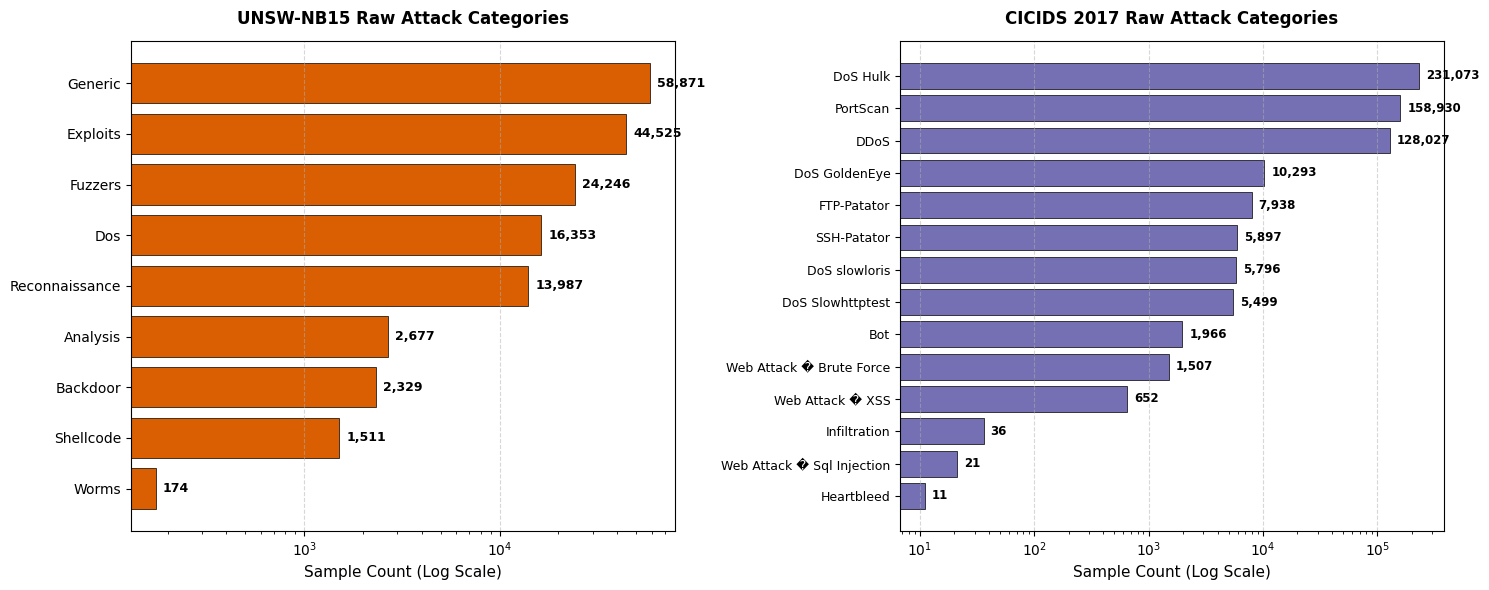

In [2]:
def plot_raw_attack_breakdown(unsw_sum, cicids_sum):
    fig, axes = plt.subplots(1, 2, figsize=(15, 6))
    
    # 1. UNSW-NB15 Attack Categories
    if unsw_sum and unsw_sum['categories'] is not None:
        cats = unsw_sum['categories'].drop('Normal', errors='ignore')
        y_pos = np.arange(len(cats))
        
        bars = axes[0].barh(y_pos, cats.values, color='#d95f02', edgecolor='black', linewidth=0.5)
        axes[0].set_yticks(y_pos)
        axes[0].set_yticklabels(cats.index, fontsize=10)
        axes[0].invert_yaxis()  # Najliczniejsze na górze
        axes[0].set_xscale('log')
        axes[0].set_xlabel('Sample Count (Log Scale)', fontsize=11)
        axes[0].set_title('UNSW-NB15 Raw Attack Categories', fontweight='bold', pad=12)
        axes[0].grid(axis='x', linestyle='--', alpha=0.5)
        
        # Add labels
        for bar in bars:
            width = bar.get_width()
            axes[0].annotate(f'{width:,}',
                             xy=(width, bar.get_y() + bar.get_height() / 2),
                             xytext=(5, 0), textcoords="offset points",
                             ha='left', va='center', fontsize=9, fontweight='bold')

    # 2. CICIDS 2017 Attack Categories
    if cicids_sum and cicids_sum['categories'] is not None:
        cats = cicids_sum['categories'].drop('BENIGN', errors='ignore')
        y_pos = np.arange(len(cats))
        
        bars = axes[1].barh(y_pos, cats.values, color='#7570b3', edgecolor='black', linewidth=0.5)
        axes[1].set_yticks(y_pos)
        axes[1].set_yticklabels(cats.index, fontsize=9)
        axes[1].invert_yaxis()
        axes[1].set_xscale('log')
        axes[1].set_xlabel('Sample Count (Log Scale)', fontsize=11)
        axes[1].set_title('CICIDS 2017 Raw Attack Categories', fontweight='bold', pad=12)
        axes[1].grid(axis='x', linestyle='--', alpha=0.5)
        
        for bar in bars:
            width = bar.get_width()
            axes[1].annotate(f'{width:,}',
                             xy=(width, bar.get_y() + bar.get_height() / 2),
                             xytext=(5, 0), textcoords="offset points",
                             ha='left', va='center', fontsize=8.5, fontweight='bold')

    plt.tight_layout()
    plt.savefig('../figures/figure3_raw_attack_categories.png', dpi=300)
    plt.savefig('../figures/figure3_raw_attack_categories.pdf')
    plt.show()

plot_raw_attack_breakdown(unsw_raw_sum, cicids_raw_sum)

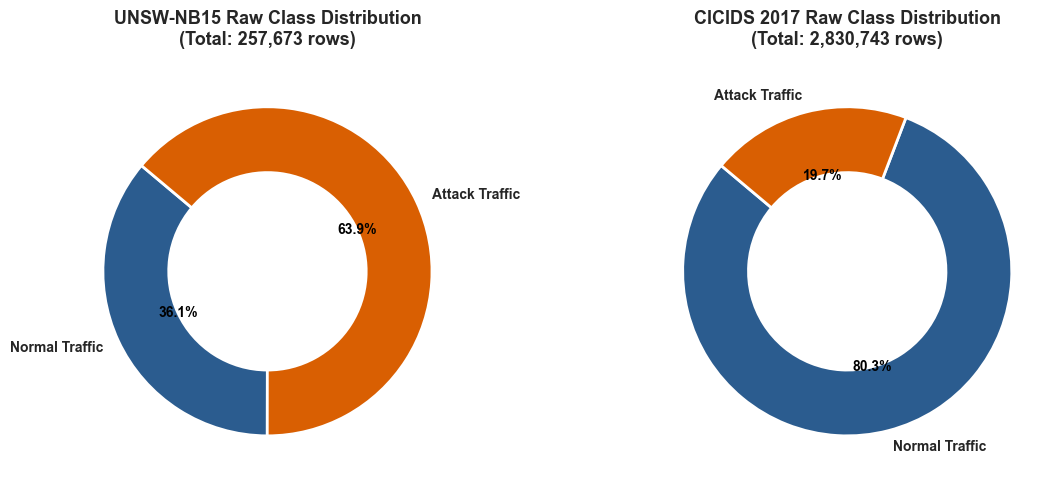

In [9]:
def plot_raw_vs_processed_summary(unsw_raw_sum, cicids_raw_sum):
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    
    datasets = [
        ('UNSW-NB15', unsw_raw_sum, axes[0]),
        ('CICIDS 2017', cicids_raw_sum, axes[1])
    ]
    
    for name, summary, ax in datasets:
        if not summary:
            continue
            
        labels = ['Normal Traffic', 'Attack Traffic']
        counts = [summary['normal_count'], summary['attack_count']]
        colors = ['#2b5c8f', '#d95f02']
        
        wedges, texts, autotexts = ax.pie(
            counts, 
            labels=labels, 
            autopct='%1.1f%%',
            startangle=140,
            colors=colors,
            wedgeprops=dict(width=0.4, edgecolor='white', linewidth=2), # Donut chart
            textprops=dict(fontsize=10, fontweight='bold')
        )
        
        # Zmiana koloru tekstu wewnątrz wykresu
        for autotext in autotexts:
            autotext.set_color('black')
            
        ax.set_title(f"{name} Raw Class Distribution\n(Total: {summary['total_rows']:,} rows)", fontweight='bold', pad=15)

    plt.tight_layout()
    plt.savefig('../figures/figure4_raw_class_distributions.png', dpi=300)
    plt.savefig('../figures/figure4_raw_class_distributions.pdf')
    plt.show()

plot_raw_vs_processed_summary(unsw_raw_sum, cicids_raw_sum)

In [4]:
def generate_raw_latex_table(unsw_sum, cicids_sum):
    rows = []
    if unsw_sum:
        rows.append({
            'Dataset': 'UNSW-NB15 (Raw)',
            'Total Samples': f"{unsw_sum['total_rows']:,}",
            'Normal (0)': f"{unsw_sum['normal_count']:,}",
            'Attack (1)': f"{unsw_sum['attack_count']:,}",
            'Attack Ratio': f"{(unsw_sum['attack_count']/unsw_sum['total_rows']*100):.2f}%"
        })
    if cicids_sum:
        rows.append({
            'Dataset': 'CICIDS 2017 (Raw)',
            'Total Samples': f"{cicids_sum['total_rows']:,}",
            'Normal (0)': f"{cicids_sum['normal_count']:,}",
            'Attack (1)': f"{cicids_sum['attack_count']:,}",
            'Attack Ratio': f"{(cicids_sum['attack_count']/cicids_sum['total_rows']*100):.2f}%"
        })
        
    df = pd.DataFrame(rows)
    latex_code = df.to_latex(
        index=False,
        caption="Overview of original raw datasets prior to ETL preprocessing and anomaly isolation.",
        label="tab:raw_datasets_summary",
        column_format="lrrrr",
        position="htbp"
    )
    
    print("=================== TABELA LATEX: SUROWE DANE ===================")
    print(latex_code)

generate_raw_latex_table(unsw_raw_sum, cicids_raw_sum)

=================== TABELA LATEX: SUROWE DANE ===================
\begin{table}[htbp]
\caption{Overview of original raw datasets prior to ETL preprocessing and anomaly isolation.}
\label{tab:raw_datasets_summary}
\begin{tabular}{lrrrr}
\toprule
Dataset & Total Samples & Normal (0) & Attack (1) & Attack Ratio \\
\midrule
UNSW-NB15 (Raw) & 257,673 & 93,000 & 164,673 & 63.91% \\
CICIDS 2017 (Raw) & 2,830,743 & 2,273,097 & 557,646 & 19.70% \\
\bottomrule
\end{tabular}
\end{table}



In [5]:
import os
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Ustawienia stylu publikacyjnego
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams.update({
    'font.family': 'sans-serif',
    'font.size': 11,
    'axes.labelsize': 12,
    'axes.titlesize': 13,
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
    'legend.fontsize': 10,
    'figure.titlesize': 14,
    'savefig.dpi': 300,
    'savefig.bbox': 'tight'
})

PROCESSED_DIR = Path("../data/processed")

def get_split_stats(dataset_prefix, label_col='label'):
    """Wczytuje zbiory z dysku i wylicza statystyki liczebności."""
    files = {
        'Train (Pure Normal)': f"{dataset_prefix}_train.csv",
        'Val Tune (Optuna)': f"{dataset_prefix}_val_tune.csv",
        'Val Calib (Threshold)': f"{dataset_prefix}_val_calib.csv",
        'Test (Frozen)': f"{dataset_prefix}_test.csv"
    }
    
    stats = []
    for split_name, filename in files.items():
        filepath = PROCESSED_DIR / filename
        if not filepath.exists():
            continue
        
        df = pd.read_csv(filepath, usecols=lambda col: col.lower() in ['label', 'label_col'])
        # Dopasowanie nazwy kolumny etykiety
        target_col = [c for c in df.columns if c.lower() == 'label'][0]
        
        total = len(df)
        pos = int((df[target_col] == 1).sum())
        neg = total - pos
        
        stats.append({
            'Split': split_name,
            'Normal': neg,
            'Attack': pos,
            'Total': total,
            'Attack Ratio (%)': (pos / total * 100) if total > 0 else 0.0
        })
    return pd.DataFrame(stats)

# Przykład użycia (pobiera statystyki z wygenerowanych CSV)
unsw_df = get_split_stats("UNSW_NB15")
cicids_df = get_split_stats("CICIDS2017")

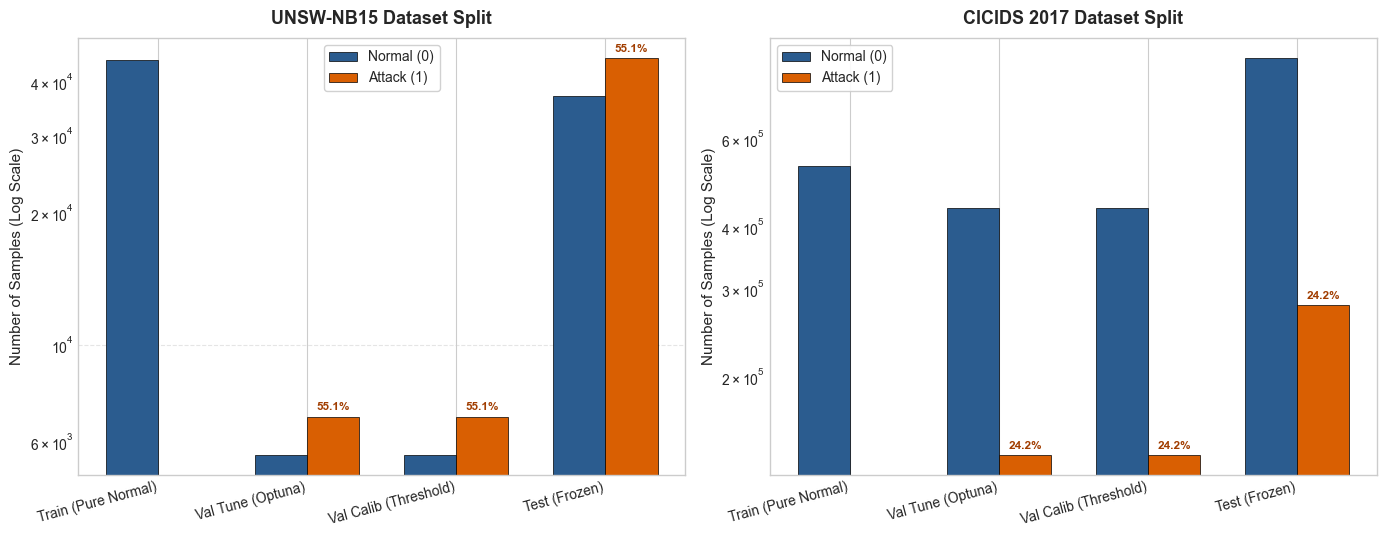

In [6]:
def plot_dataset_composition(unsw_df, cicids_df):
    fig, axes = plt.subplots(1, 2, figsize=(14, 5.5), sharey=False)
    
    colors = {'Normal': '#2b5c8f', 'Attack': '#d95f02'}
    
    datasets = [('UNSW-NB15 Dataset Split', unsw_df, axes[0]), 
                ('CICIDS 2017 Dataset Split', cicids_df, axes[1])]
    
    for title, df, ax in datasets:
        if df.empty:
            ax.text(0.5, 0.5, f"Brak danych dla {title}", ha='center', va='center')
            continue
            
        x = np.arange(len(df['Split']))
        width = 0.35
        
        rects1 = ax.bar(x - width/2, df['Normal'], width, label='Normal (0)', color=colors['Normal'], edgecolor='black', linewidth=0.5)
        rects2 = ax.bar(x + width/2, df['Attack'], width, label='Attack (1)', color=colors['Attack'], edgecolor='black', linewidth=0.5)
        
        ax.set_ylabel('Number of Samples (Log Scale)', fontsize=11)
        ax.set_title(title, fontweight='bold', pad=10)
        ax.set_xticks(x)
        ax.set_xticklabels(df['Split'], rotation=15, ha='right')
        ax.set_yscale('log')  # Skala logarytmiczna dla przejrzystości
        ax.legend(frameon=True, facecolor='white', framealpha=0.9)
        ax.grid(axis='y', linestyle='--', alpha=0.5)
        
        # Etykiety procentowe nad słupkami ataków
        for i, row in df.iterrows():
            if row['Attack'] > 0:
                ax.annotate(f"{row['Attack Ratio (%)']:.1f}%",
                            xy=(i + width/2, row['Attack']),
                            xytext=(0, 3), textcoords="offset points",
                            ha='center', va='bottom', fontsize=8.5, fontweight='bold', color='#a13d00')

    plt.tight_layout()
    plt.savefig('../figures/figure1_dataset_splits.png', dpi=300)
    plt.savefig('../figures/figure1_dataset_splits.pdf') # Zapis do PDF pod LaTeX
    plt.show()

plot_dataset_composition(unsw_df, cicids_df)

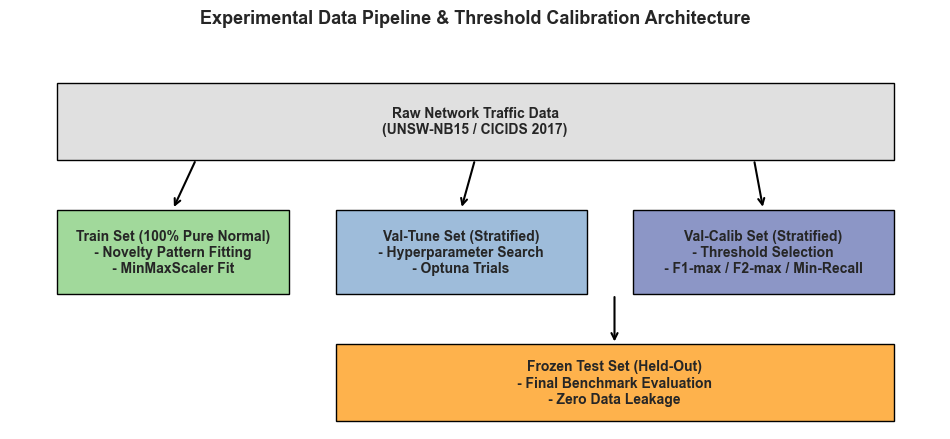

In [7]:
def plot_methodology_flow():
    fig, ax = plt.subplots(figsize=(12, 5))
    ax.axis('off')
    
    # Kolory bloków
    c_raw = '#e0e0e0'
    c_train = '#a1d99b'
    c_tune = '#9ebcda'
    c_calib = '#8c96c6'
    c_test = '#feb24c'

    # Rysowanie bloków (Rectangle: x, y, width, height)
    boxes = [
        (0.05, 0.70, 0.90, 0.20, c_raw, "Raw Network Traffic Data\n(UNSW-NB15 / CICIDS 2017)"),
        
        (0.05, 0.35, 0.25, 0.22, c_train, "Train Set (100% Pure Normal)\n- Novelty Pattern Fitting\n- MinMaxScaler Fit"),
        (0.35, 0.35, 0.27, 0.22, c_tune, "Val-Tune Set (Stratified)\n- Hyperparameter Search\n- Optuna Trials"),
        (0.67, 0.35, 0.28, 0.22, c_calib, "Val-Calib Set (Stratified)\n- Threshold Selection\n- F1-max / F2-max / Min-Recall"),
        
        (0.35, 0.02, 0.60, 0.20, c_test, "Frozen Test Set (Held-Out)\n- Final Benchmark Evaluation\n- Zero Data Leakage")
    ]

    for x, y, w, h, col, text in boxes:
        ax.add_patch(plt.Rectangle((x, y), w, h, facecolor=col, edgecolor='black'))
        ax.text(x + w/2, y + h/2, text, ha='center', va='center', fontsize=10, fontweight='bold', multialignment='center')

    # Strzałki przepływu
    arrowprops = dict(arrowstyle="->", lw=1.5, color='black')
    
    # Z Raw Data do podzbiorów
    ax.annotate('', xy=(0.175, 0.57), xytext=(0.20, 0.70), arrowprops=arrowprops)
    ax.annotate('', xy=(0.485, 0.57), xytext=(0.50, 0.70), arrowprops=arrowprops)
    ax.annotate('', xy=(0.810, 0.57), xytext=(0.80, 0.70), arrowprops=arrowprops)
    
    # Do Testu
    ax.annotate('', xy=(0.65, 0.22), xytext=(0.65, 0.35), arrowprops=arrowprops)

    plt.title("Experimental Data Pipeline & Threshold Calibration Architecture", fontsize=13, fontweight='bold', pad=15)
    plt.savefig('../figures/figure2_pipeline_architecture.png', dpi=300)
    plt.savefig('../figures/figure2_pipeline_architecture.pdf')
    plt.show()

plot_methodology_flow()

In [8]:
def generate_latex_table(unsw_df, cicids_df):
    def format_df(df, dataset_name):
        df_copy = df.copy()
        df_copy['Dataset'] = dataset_name
        return df_copy

    combined = pd.concat([format_df(unsw_df, "UNSW-NB15"), format_df(cicids_df, "CICIDS 2017")])
    combined = combined[['Dataset', 'Split', 'Normal', 'Attack', 'Total', 'Attack Ratio (%)']]
    
    latex_code = combined.to_latex(
        index=False,
        caption="Summary of dataset splits, absolute sample counts, and natural attack ratios.",
        label="tab:dataset_splits",
        column_format="llrrr r",
        position="htbp"
    )
    
    print("=================== KOD LATEX DO ARTYKUŁU ===================")
    print(latex_code)

generate_latex_table(unsw_df, cicids_df)

=================== KOD LATEX DO ARTYKUŁU ===================
\begin{table}[htbp]
\caption{Summary of dataset splits, absolute sample counts, and natural attack ratios.}
\label{tab:dataset_splits}
\begin{tabular}{llrrr r}
\toprule
Dataset & Split & Normal & Attack & Total & Attack Ratio (%) \\
\midrule
UNSW-NB15 & Train (Pure Normal) & 44800 & 0 & 44800 & 0.000000 \\
UNSW-NB15 & Val Tune (Optuna) & 5600 & 6861 & 12461 & 55.059787 \\
UNSW-NB15 & Val Calib (Threshold) & 5600 & 6861 & 12461 & 55.059787 \\
UNSW-NB15 & Test (Frozen) & 37000 & 45332 & 82332 & 55.060001 \\
CICIDS 2017 & Train (Pure Normal) & 529481 & 0 & 529481 & 0.000000 \\
CICIDS 2017 & Val Tune (Optuna) & 435459 & 139139 & 574598 & 24.215016 \\
CICIDS 2017 & Val Calib (Threshold) & 435460 & 139139 & 574599 & 24.214974 \\
CICIDS 2017 & Test (Frozen) & 870920 & 278278 & 1149198 & 24.214974 \\
\bottomrule
\end{tabular}
\end{table}

